In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (roc_auc_score, recall_score,
                             precision_score, f1_score,
                             confusion_matrix, classification_report)
from imblearn.over_sampling import SMOTE
import joblib
import os
import warnings
warnings.filterwarnings('ignore')

print("All libraries loaded!")

All libraries loaded!


In [22]:
# Load engineered dataset from 03_feature_engineering
df = pd.read_csv("../data/processed/diabetic_engineered.csv")

print(f"Rows: {len(df):,}")
print(f"Columns: {df.shape[1]}")
print(f"Target distribution:")
print(f"  Not Readmitted (0): {(df['readmitted_30']==0).sum():,} ({(df['readmitted_30']==0).mean()*100:.1f}%)")
print(f"  Readmitted <30 (1): {(df['readmitted_30']==1).sum():,} ({(df['readmitted_30']==1).mean()*100:.1f}%)")
print(f"Class imbalance confirmed — ROC-AUC will be primary metric")

Rows: 101,766
Columns: 45
Target distribution:
  Not Readmitted (0): 90,409 (88.8%)
  Readmitted <30 (1): 11,357 (11.2%)
Class imbalance confirmed — ROC-AUC will be primary metric


In [23]:
## 70/15/15 Train/Validation/Test Split
# Separate features and target
X = df.drop(columns=['readmitted_30'])
y = df['readmitted_30']

print(f"Features: {X.shape[1]}")
print(f"Samples:  {len(y):,}")

# First split: 70% train, 30% temp
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

# Second split: 50/50 of temp = 15% val, 15% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

Features: 44
Samples:  101,766


In [24]:
print(f"Split sizes:")
print(f"  Training: {len(X_train):,} rows ({len(X_train)/len(X)*100:.0f}%)")
print(f"  Validation: {len(X_val):,} rows ({len(X_val)/len(X)*100:.0f}%)")
print(f"  Test: {len(X_test):,} rows ({len(X_test)/len(X)*100:.0f}%)")

Split sizes:
  Training: 71,236 rows (70%)
  Validation: 15,265 rows (15%)
  Test: 15,265 rows (15%)


In [25]:
print(f"Class balance in each split:")
print(f"  Train positive rate: {y_train.mean()*100:.1f}%")
print(f"  Val positive rate: {y_val.mean()*100:.1f}%")
print(f"  Test positive rate: {y_test.mean()*100:.1f}%")

Class balance in each split:
  Train positive rate: 11.2%
  Val positive rate: 11.2%
  Test positive rate: 11.2%


In [26]:
# Apply SMOTE to training set only
print("Applying SMOTE to training set only")

smote = SMOTE(random_state=42, k_neighbors=5)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print("SMOTE applied!")
print(f"Before SMOTE:")
print(f"  Class 0: {(y_train==0).sum():,} ({(y_train==0).mean()*100:.1f}%)")
print(f"  Class 1: {(y_train==1).sum():,} ({(y_train==1).mean()*100:.1f}%)")
print(f"After SMOTE:")
print(f"  Class 0: {(y_train_sm==0).sum():,} ({(y_train_sm==0).mean()*100:.1f}%)")
print(f"  Class 1: {(y_train_sm==1).sum():,} ({(y_train_sm==1).mean()*100:.1f}%)")
print(f"  New training size: {len(X_train_sm):,} rows")
print(f"Validation set — NOT resampled:")
print(f"  Class 0: {(y_val==0).sum():,} ({(y_val==0).mean()*100:.1f}%)")
print(f"  Class 1: {(y_val==1).sum():,} ({(y_val==1).mean()*100:.1f}%)")

Applying SMOTE to training set only
SMOTE applied!
Before SMOTE:
  Class 0: 63,286 (88.8%)
  Class 1: 7,950 (11.2%)
After SMOTE:
  Class 0: 63,286 (50.0%)
  Class 1: 63,286 (50.0%)
  New training size: 126,572 rows
Validation set — NOT resampled:
  Class 0: 13,561 (88.8%)
  Class 1: 1,704 (11.2%)


In [27]:
## --- Scale features ---
# Fit scaler on SMOTE training data only
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_sm)
X_val_scaled   = scaler.transform(X_val)    # transform only
X_test_scaled  = scaler.transform(X_test)   # transform only

# Save scaler and feature names to models/ folder
joblib.dump(scaler, '../models/scaler.pkl')
joblib.dump(list(X_train.columns), '../models/feature_names.pkl')

print("Features scaled!")
print(f"Scaler fitted on: SMOTE training data only")
print(f"Applied to: Validation and test sets")
print(f"Saved:")
print(f"  models/scaler.pkl")
print(f"  models/feature_names.pkl")

Features scaled!
Scaler fitted on: SMOTE training data only
Applied to: Validation and test sets
Saved:
  models/scaler.pkl
  models/feature_names.pkl


In [33]:
## --- Model 1 : Logistic Regression (baseline) ---
print("Training Logistic Regression")

lr = LogisticRegression(
    max_iter=1000,
    random_state=42,
    class_weight='balanced'
)

lr.fit(X_train_scaled, y_train_sm)

# Evaluate on VALIDATION set only
y_val_prob_lr = lr.predict_proba(X_val_scaled)[:, 1]
y_val_pred_lr = (y_val_prob_lr >= 0.5).astype(int)

auc_lr  = roc_auc_score(y_val, y_val_prob_lr)
rec_lr  = recall_score(y_val, y_val_pred_lr)
prec_lr = precision_score(y_val, y_val_pred_lr)
f1_lr   = f1_score(y_val, y_val_pred_lr)

print("Logistic Regression done!")
print(f"Validation Results:")
print(f"  ROC-AUC: {auc_lr:.4f}")
print(f"  Recall: {rec_lr:.4f}")
print(f"  Precision: {prec_lr:.4f}")
print(f"  F1-Score: {f1_lr:.4f}")

Training Logistic Regression
Logistic Regression done!
Validation Results:
  ROC-AUC: 0.5996
  Recall: 0.0117
  Precision: 0.3448
  F1-Score: 0.0227


In [34]:
# Lower threshold to improve recall
# Default 0.5 is too high for imbalanced validation set
# Use 0.3 threshold instead

y_val_pred_lr = (y_val_prob_lr >= 0.3).astype(int)

auc_lr  = roc_auc_score(y_val, y_val_prob_lr)
rec_lr  = recall_score(y_val, y_val_pred_lr)
prec_lr = precision_score(y_val, y_val_pred_lr)
f1_lr   = f1_score(y_val, y_val_pred_lr)

print("Logistic Regression (threshold=0.3)")
print(f"Validation Results:")
print(f"  ROC-AUC: {auc_lr:.4f}")
print(f"  Recall: {rec_lr:.4f}")
print(f"  Precision: {prec_lr:.4f}")
print(f"  F1-Score: {f1_lr:.4f}")
print(f"\nConfusion Matrix:")
cm = confusion_matrix(y_val, y_val_pred_lr)
print(f"  True Negatives: {cm[0][0]:,}")
print(f"  False Positives: {cm[0][1]:,}")
print(f"  False Negatives: {cm[1][0]:,}")
print(f"  True Positives: {cm[1][1]:,}")

Logistic Regression (threshold=0.3)
Validation Results:
  ROC-AUC: 0.5996
  Recall: 0.0816
  Precision: 0.2598
  F1-Score: 0.1242

Confusion Matrix:
  True Negatives: 13,165
  False Positives: 396
  False Negatives: 1,565
  True Positives: 139


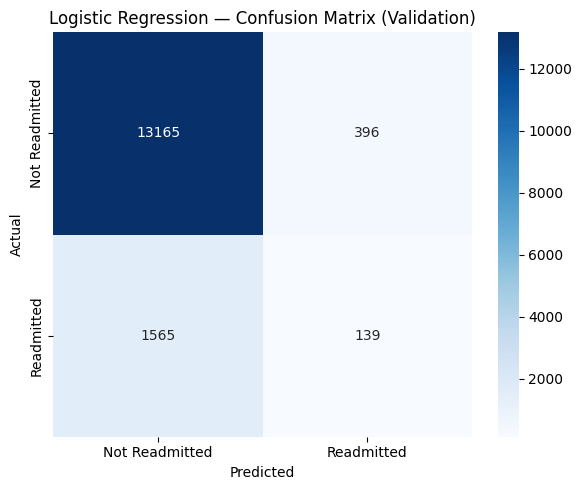

Saved dashboard/lr_confusion_matrix.png


In [35]:
# Plot and save confusion matrix
fig, ax = plt.subplots(figsize=(6, 5))
cm_lr = confusion_matrix(y_val, y_val_pred_lr)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Not Readmitted', 'Readmitted'],
            yticklabels=['Not Readmitted', 'Readmitted'])
ax.set_title('Logistic Regression — Confusion Matrix (Validation)')
ax.set_ylabel('Actual')
ax.set_xlabel('Predicted')
plt.tight_layout()
plt.savefig('../dashboard/lr_confusion_matrix.png', 
            bbox_inches='tight', dpi=150)
plt.show()
print("Saved dashboard/lr_confusion_matrix.png")

In [ ]:
## --- Model 2 : Random Forest Training ---
print("Training Random Forest")

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    min_samples_leaf=5,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train_sm, y_train_sm)

# Evaluate on VALIDATION set (unscaled - RF doesn't need scaling)
y_val_prob_rf = rf.predict_proba(X_val)[:, 1]
y_val_pred_rf = (y_val_prob_rf >= 0.5).astype(int)

auc_rf  = roc_auc_score(y_val, y_val_prob_rf)
rec_rf  = recall_score(y_val, y_val_pred_rf)
prec_rf = precision_score(y_val, y_val_pred_rf)
f1_rf   = f1_score(y_val, y_val_pred_rf)

print("Random Forest done!")
print(f"Validation Results:")
print(f"  ROC-AUC: {auc_rf:.4f}")
print(f"  Recall: {rec_rf:.4f}")
print(f"  Precision: {prec_rf:.4f}")
print(f"  F1-Score: {f1_rf:.4f}")

Training Random Forest
Random Forest done!
Validation Results:
  ROC-AUC: 0.6041
  Recall: 0.1127
  Precision: 0.1793
  F1-Score: 0.1384


In [37]:
# Model 3 : XGBoost (clinical only)
print("Training XGBoost (clinical only)")

clinical_features = ['age', 'time_in_hospital', 'num_lab_procedures',
                     'num_procedures', 'num_medications', 'number_outpatient',
                     'number_emergency', 'number_inpatient', 'number_diagnoses',
                     'admission_type_id', 'discharge_disposition_id',
                     'admission_source_id', 'medical_specialty',
                     'diag_1', 'diag_2', 'diag_3']

xgb_clinical = XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=6,
    random_state=42,
    eval_metric='logloss',
    verbosity=0
)

xgb_clinical.fit(X_train_sm[clinical_features], y_train_sm)

# Evaluate on validation set
y_val_prob_xgb_c = xgb_clinical.predict_proba(X_val[clinical_features])[:, 1]
y_val_pred_xgb_c = (y_val_prob_xgb_c >= 0.5).astype(int)

auc_xgb_c  = roc_auc_score(y_val, y_val_prob_xgb_c)
rec_xgb_c  = recall_score(y_val, y_val_pred_xgb_c)
prec_xgb_c = precision_score(y_val, y_val_pred_xgb_c)
f1_xgb_c   = f1_score(y_val, y_val_pred_xgb_c)

print("XGBoost (clinical only) done!")
print(f"Validation Results:")
print(f"  ROC-AUC: {auc_xgb_c:.4f}")
print(f"  Recall: {rec_xgb_c:.4f}")
print(f"  Precision: {prec_xgb_c:.4f}")
print(f"  F1-Score: {f1_xgb_c:.4f}")

Training XGBoost (clinical only)
XGBoost (clinical only) done!
Validation Results:
  ROC-AUC: 0.6043
  Recall: 0.2541
  Precision: 0.1675
  F1-Score: 0.2019


In [38]:
## --- Model 4 : XGBoost (multi-source - all features) ---
print("Training XGBoost (multi-source)...")

xgb_multi = XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=6,
    random_state=42,
    eval_metric='logloss',
    verbosity=0
)

xgb_multi.fit(X_train_sm, y_train_sm)

# Evaluate on validation set
y_val_prob_xgb_m = xgb_multi.predict_proba(X_val)[:, 1]
y_val_pred_xgb_m = (y_val_prob_xgb_m >= 0.5).astype(int)

auc_xgb_m  = roc_auc_score(y_val, y_val_prob_xgb_m)
rec_xgb_m  = recall_score(y_val, y_val_pred_xgb_m)
prec_xgb_m = precision_score(y_val, y_val_pred_xgb_m)
f1_xgb_m   = f1_score(y_val, y_val_pred_xgb_m)

print("XGBoost (multi-source) done!")
print(f"Validation Results:")
print(f"  ROC-AUC: {auc_xgb_m:.4f}")
print(f"  Recall: {rec_xgb_m:.4f}")
print(f"  Precision: {prec_xgb_m:.4f}")
print(f"  F1-Score: {f1_xgb_m:.4f}")

Training XGBoost (multi-source)...
XGBoost (multi-source) done!
Validation Results:
  ROC-AUC: 0.6332
  Recall: 0.0423
  Precision: 0.3172
  F1-Score: 0.0746


In [40]:
# Model comparison table
results = pd.DataFrame({
    'Model': [
        'Logistic Regression (baseline)',
        'Random Forest',
        'XGBoost (clinical only)',
        'XGBoost (multi-source)'
    ],
    'ROC-AUC':   [auc_lr,    auc_rf,    auc_xgb_c,  auc_xgb_m],
    'Recall':    [rec_lr,    rec_rf,    rec_xgb_c,  rec_xgb_m],
    'Precision': [prec_lr,   prec_rf,   prec_xgb_c, prec_xgb_m],
    'F1-Score':  [f1_lr,     f1_rf,     f1_xgb_c,   f1_xgb_m],
    'Data':      ['Clinical', 'Clinical', 'Clinical', 'Multi-source'],
    'SMOTE':     ['Yes', 'Yes', 'Yes', 'Yes']
})

results = results.round(4)

print("-" * 75)
print("MODEL COMPARISON TABLE (Validation Set)")
print("-" * 75)
print(results.to_string(index=False))
print("-" * 75)
print(f"Best ROC-AUC: XGBoost (multi-source) — {auc_xgb_m:.4f}")
print(f"Improvement over LR baseline: +{(auc_xgb_m - auc_lr):.4f}")

# Save to dashboard
results.to_csv('../dashboard/model_comparison.csv', index=False)
print("Model comparison saved to dashboard/model_comparison.csv")

---------------------------------------------------------------------------
MODEL COMPARISON TABLE (Validation Set)
---------------------------------------------------------------------------
                         Model  ROC-AUC  Recall  Precision  F1-Score         Data SMOTE
Logistic Regression (baseline)   0.5996  0.0816     0.2598    0.1242     Clinical   Yes
                 Random Forest   0.6041  0.1127     0.1793    0.1384     Clinical   Yes
       XGBoost (clinical only)   0.6043  0.2541     0.1675    0.2019     Clinical   Yes
        XGBoost (multi-source)   0.6332  0.0423     0.3172    0.0746 Multi-source   Yes
---------------------------------------------------------------------------
Best ROC-AUC: XGBoost (multi-source) — 0.6332
Improvement over LR baseline: +0.0336
Model comparison saved to dashboard/model_comparison.csv


In [41]:
# Save all trained models
joblib.dump(lr,          '../models/model_lr.pkl')
joblib.dump(rf,          '../models/model_rf.pkl')
joblib.dump(xgb_clinical,'../models/model_xgb_clinical.pkl')
joblib.dump(xgb_multi,   '../models/model_xgb_multi.pkl')

print("All models saved!")
print("  models/model_lr.pkl")
print("  models/model_rf.pkl")
print("  models/model_xgb_clinical.pkl")
print("  models/model_xgb_multi.pkl")

# Save data splits for Week 6
np.save('../data/processed/X_train_sm.npy',  X_train_sm.values)
np.save('../data/processed/y_train_sm.npy',  y_train_sm.values)
np.save('../data/processed/X_val.npy', X_val.values)
np.save('../data/processed/y_val.npy', y_val.values)
np.save('../data/processed/X_test.npy', X_test.values)
np.save('../data/processed/y_test.npy', y_test.values)

print("Data splits saved!")
print("  data/processed/X_train_sm.npy")
print("  data/processed/X_val.npy")
print("  data/processed/X_test.npy")

All models saved!
  models/model_lr.pkl
  models/model_rf.pkl
  models/model_xgb_clinical.pkl
  models/model_xgb_multi.pkl
Data splits saved!
  data/processed/X_train_sm.npy
  data/processed/X_val.npy
  data/processed/X_test.npy


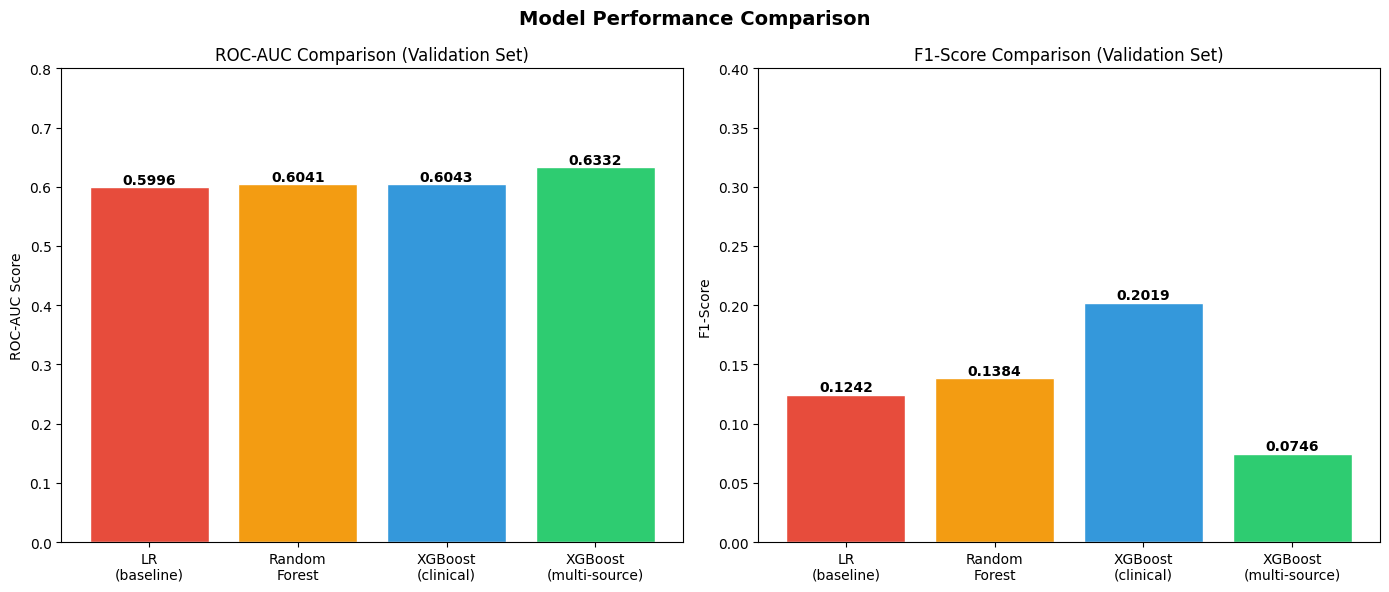

Model comparison chart saved!


In [43]:
# Plot model comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

models_short = ['LR\n(baseline)', 'Random\nForest', 
                'XGBoost\n(clinical)', 'XGBoost\n(multi-source)']
colors = ['#e74c3c', '#f39c12', '#3498db', '#2ecc71']

# ROC-AUC comparison
roc_values = [auc_lr, auc_rf, auc_xgb_c, auc_xgb_m]
bars = axes[0].bar(models_short, roc_values, 
                   color=colors, edgecolor='white')
axes[0].set_title('ROC-AUC Comparison (Validation Set)')
axes[0].set_ylabel('ROC-AUC Score')
axes[0].set_ylim(0, 0.8)
for bar, val in zip(bars, roc_values):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                val + 0.005, f'{val:.4f}',
                ha='center', fontsize=10, fontweight='bold')

# F1 comparison
f1_values = [f1_lr, f1_rf, f1_xgb_c, f1_xgb_m]
bars2 = axes[1].bar(models_short, f1_values,
                    color=colors, edgecolor='white')
axes[1].set_title('F1-Score Comparison (Validation Set)')
axes[1].set_ylabel('F1-Score')
axes[1].set_ylim(0, 0.4)
for bar, val in zip(bars2, f1_values):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                val + 0.003, f'{val:.4f}',
                ha='center', fontsize=10, fontweight='bold')

plt.suptitle('Model Performance Comparison', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../dashboard/model_comparison.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Model comparison chart saved!")

In [45]:
import os

print("models/")
for f in sorted(os.listdir("../models/")):
    size = os.path.getsize(f"../models/{f}")
    print(f"  {f} — {size/1024:.1f} KB")

print("dashboard/")
for f in sorted(os.listdir("../dashboard/")):
    size = os.path.getsize(f"../dashboard/{f}")
    print(f"  {f} — {size/1024:.1f} KB")

models/
  best_model_fulldataset.pkl — 279964.1 KB
  feature_names.pkl — 0.7 KB
  model_lr.pkl — 1.2 KB
  model_rf.pkl — 88950.3 KB
  model_xgb_clinical.pkl — 802.0 KB
  model_xgb_multi.pkl — 727.9 KB
  scaler.pkl — 2.5 KB
dashboard/
  age_analysis.png — 68.5 KB
  clinical_features.png — 149.4 KB
  correlation_heatmap.png — 180.7 KB
  diagnosis_analysis.png — 96.7 KB
  gender_analysis.png — 41.1 KB
  inpatient_analysis.png — 82.1 KB
  lr_confusion_matrix.png — 40.1 KB
  model_comparison.csv — 0.3 KB
  model_comparison.png — 72.2 KB
  model_comparison_fulldataset.csv — 0.3 KB
  model_comparison_fulldataset.png — 64.1 KB
  patient_risk_scores.csv — 2036.3 KB
  race_analysis.png — 49.8 KB
  roc_curve_fulldataset.png — 59.7 KB
  sdoh_features.png — 173.4 KB
  summary_statistics.csv — 1.1 KB
  target_distribution.png — 73.2 KB
  ttest_results.csv — 0.4 KB
